In [39]:
import numpy as np

In [40]:
rain = np.fromfile(
    "../data/raw/Rainfall_ind2024_rfp25.grd",
    dtype=np.float32
)

print(rain.shape)

(6373890,)


In [41]:
rain = rain.reshape(366,129,135)

print(rain.shape)

(366, 129, 135)


In [42]:
print(rain.min())
print(rain.max())

-999.0
660.5492


In [43]:
rain = np.where(
    rain == -999,
    np.nan,
    rain
)

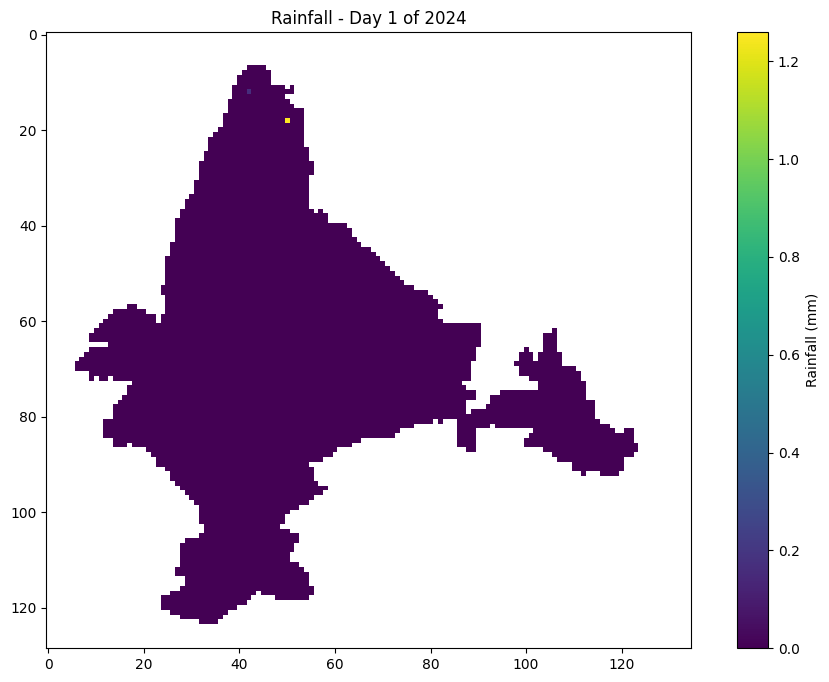

In [44]:
import matplotlib.pyplot as plt

day0 = rain[0]

plt.figure(figsize=(12,8))
plt.imshow(day0)
plt.colorbar(label="Rainfall (mm)")
plt.title("Rainfall - Day 1 of 2024")
plt.show()

In [45]:
print("Mean:", np.nanmean(rain))
print("Median:", np.nanmedian(rain))
print("Max:", np.nanmax(rain))

Mean: 3.3205583
Median: 0.0
Max: 660.5492


In [46]:
rain = np.fromfile(
    "../data/raw/Rainfall_ind2024_rfp25.grd",
    dtype=np.float32
)

print(rain.shape)

(6373890,)


In [47]:
rain = np.where(
    rain == -999,
    np.nan,
    rain
)

In [48]:
latitudes = np.linspace(
    38.5,
    6.5,
    129
)

longitudes = np.linspace(
    66.5,
    100.0,
    135
)

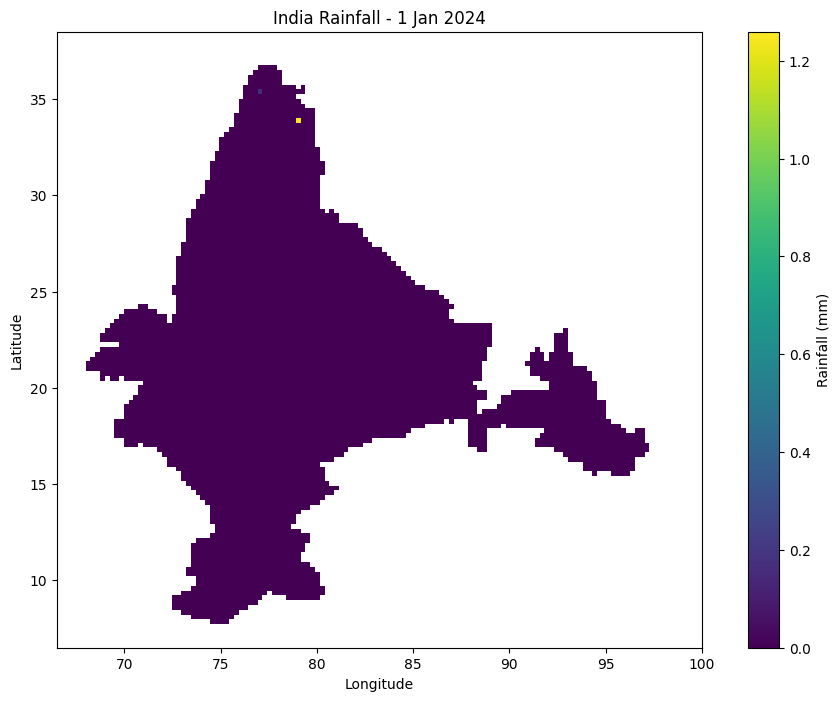

In [49]:
plt.figure(figsize=(12,8))

plt.imshow(
    day0,
    extent=[
        longitudes.min(),
        longitudes.max(),
        latitudes.min(),
        latitudes.max()
    ]
)

plt.colorbar(label="Rainfall (mm)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("India Rainfall - 1 Jan 2024")

plt.show()

In [50]:
print(np.nanmin(day0))
print(np.nanmax(day0))
print(np.nanmean(day0))

0.0
1.2592779
0.00028648382


In [51]:
daily_mean = np.nanmean(
    rain,
    axis=(1,2)
)

wettest_day = np.argmax(daily_mean)

print("Wettest Day Index:", wettest_day)
print("Mean Rainfall:", daily_mean[wettest_day])

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
print(rain.shape)

(6373890,)


In [ ]:
rain = np.fromfile(
    "../data/raw/Rainfall_ind2024_rfp25.grd",
    dtype=np.float32
)

rain = rain.reshape(366,129,135)

rain = np.where(
    rain == -999,
    np.nan,
    rain
)

print(rain.shape)

(366, 129, 135)


In [ ]:
daily_mean = np.nanmean(
    rain,
    axis=(1,2)
)

In [ ]:
daily_mean = np.nanmean(
    rain,
    axis=(1,2)
)

wettest_day = np.argmax(daily_mean)

print("Wettest Day Index:", wettest_day)
print("Mean Rainfall:", daily_mean[wettest_day])

Wettest Day Index: 215
Mean Rainfall: 15.829672


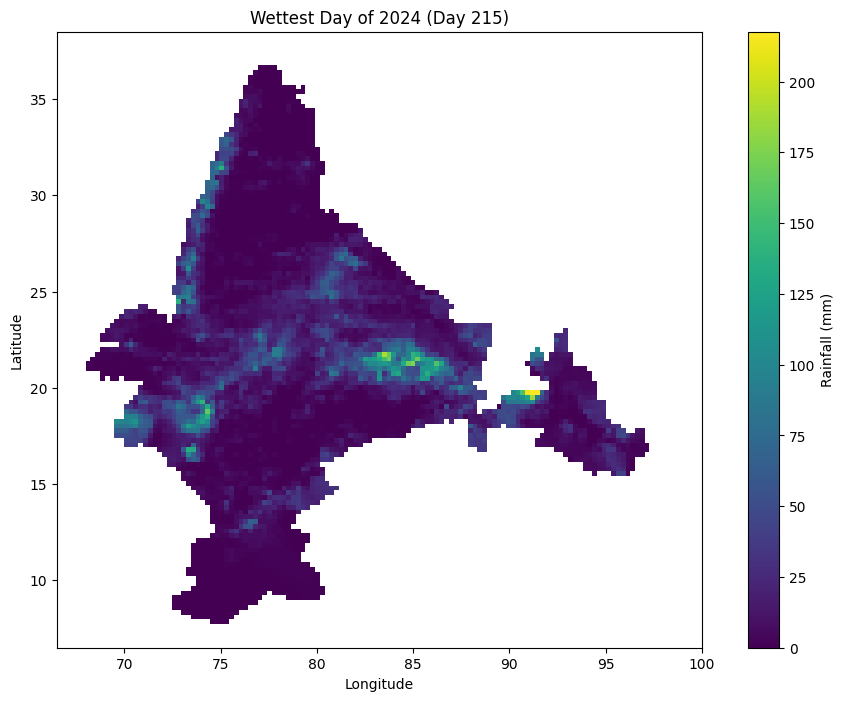

In [ ]:
wettest = rain[wettest_day]

plt.figure(figsize=(12,8))

plt.imshow(
    wettest,
    extent=[
        longitudes.min(),
        longitudes.max(),
        latitudes.min(),
        latitudes.max()
    ]
)

plt.colorbar(label="Rainfall (mm)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Wettest Day of 2024 (Day {wettest_day})")

plt.show()

In [ ]:
#Temp data

In [ ]:
temp = np.fromfile(
    "../data/raw/Maxtemp_MaxT_2024.GRD",
    dtype=np.float32
)

print(temp.shape)

(351726,)


In [ ]:
temp = temp.reshape(366,31,31)

print(temp.shape)

(366, 31, 31)


In [ ]:
print(temp.min())
print(temp.max())

3.5872378
99.9


In [ ]:
temp = np.where(
    temp == 99.9,
    np.nan,
    temp
)

In [ ]:
print("Min:", np.nanmin(temp))
print("Max:", np.nanmax(temp))
print("Mean:", np.nanmean(temp))

Min: 3.5872378
Max: 48.09463
Mean: 30.920702


In [ ]:
print(temp.shape)

(366, 31, 31)


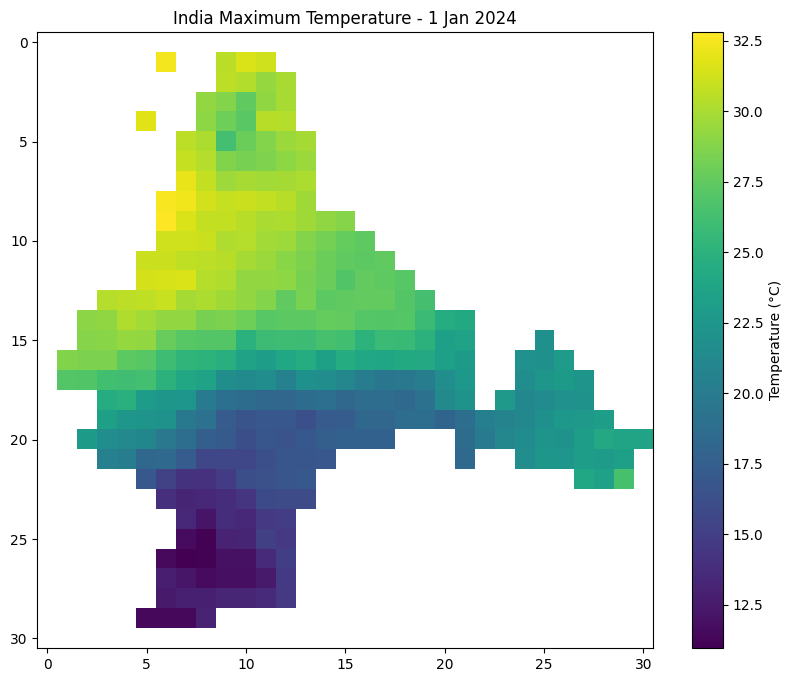

In [ ]:
day0_temp = temp[0]

plt.figure(figsize=(10,8))

plt.imshow(day0_temp)

plt.colorbar(label="Temperature (°C)")
plt.title("India Maximum Temperature - 1 Jan 2024")

plt.show()

In [ ]:
from dataclasses import dataclass


@dataclass
class ClimateState:
    date: str
    latitude: float
    longitude: float
    rainfall_mm: float
    max_temperature_c: float

In [ ]:
state = ClimateState(
    date="2024-01-01",
    latitude=19.07,
    longitude=72.88,
    rainfall_mm=0.0,
    max_temperature_c=31.2
)

print(state)

ClimateState(date='2024-01-01', latitude=19.07, longitude=72.88, rainfall_mm=0.0, max_temperature_c=31.2)


In [ ]:
import sys
sys.path.append("..")

In [ ]:
from src.ingest import (
    load_rainfall,
    load_temperature
)

In [ ]:
rain = load_rainfall()

print(rain.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/Rainfall_ind2024_rfp25.grd'

In [ ]:
import os
print(os.getcwd())

e:\ClimateTwinIndia\notebooks


In [ ]:
from src.ingest import load_rainfall

rain = load_rainfall()

print(rain.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/Rainfall_ind2024_rfp25.grd'

In [52]:
import importlib
import src.ingest

importlib.reload(src.ingest)

from src.ingest import load_rainfall

rain = load_rainfall()

print(rain.shape)

Loading rainfall from: E:\ClimateTwinIndia\data\raw\Rainfall_ind2024_rfp25.grd
(366, 129, 135)


In [53]:
from src.ingest import load_temperature

temp = load_temperature()

print(temp.shape)

Loading temperature from: E:\ClimateTwinIndia\data\raw\Maxtemp_MaxT_2024.GRD
(366, 31, 31)


In [54]:
from src.region import (
    get_rainfall_latitudes,
    get_rainfall_longitudes
)

latitudes = get_rainfall_latitudes()
longitudes = get_rainfall_longitudes()

print(latitudes.shape)
print(longitudes.shape)

(129,)
(135,)


In [55]:
lat_mask = (
    (latitudes >= 15)
    &
    (latitudes <= 23)
)

lon_mask = (
    (longitudes >= 72)
    &
    (longitudes <= 81)
)

print(lat_mask.sum())
print(lon_mask.sum())

33
37


In [56]:
maha_rain = rain[
    215,
    lat_mask,
    :
][:,
    lon_mask
]

print(maha_rain.shape)

(33, 37)


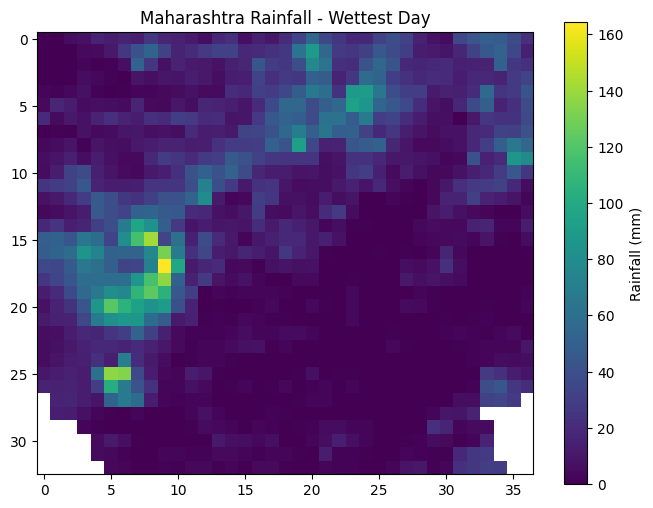

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(maha_rain)

plt.colorbar(
    label="Rainfall (mm)"
)

plt.title(
    "Maharashtra Rainfall - Wettest Day"
)

plt.show()

In [58]:
from src.climate_state import ClimateState

mumbai_state = ClimateState(
    date="2024-08-03",
    latitude=19.07,
    longitude=72.88,
    rainfall_mm=120.5,
    max_temperature_c=28.7
)

print(mumbai_state)

ClimateState(date='2024-08-03', latitude=19.07, longitude=72.88, rainfall_mm=120.5, max_temperature_c=28.7)


In [59]:
from src.trust import (
    completeness_score,
    anomaly_score
)

score = completeness_score(
    rainfall=120.5,
    temperature=28.7
)

print(score)

1.0


In [60]:
rain_mean = np.nanmean(rain)
rain_std = np.nanstd(rain)

print(rain_mean)
print(rain_std)

3.3205583
11.728829


In [61]:
anomaly = anomaly_score(
    rainfall=120.5,
    rainfall_mean=rain_mean,
    rainfall_std=rain_std
)

print(anomaly)

9.990719265794256


In [67]:
from src.climate_state import ClimateState

mumbai_state = ClimateState(
    date="2024-08-03",
    latitude=19.07,
    longitude=72.88,

    rainfall_mm=120.5,
    max_temperature_c=28.7,

    completeness_score=1.0,
    anomaly_score=4.2
)

print(mumbai_state)

TypeError: ClimateState.__init__() got an unexpected keyword argument 'completeness_score'

In [68]:
import importlib
import src.climate_state

importlib.reload(src.climate_state)

from src.climate_state import ClimateState

In [69]:
help(ClimateState)

Help on class ClimateState in module src.climate_state:

class ClimateState(builtins.object)
 |  ClimateState(date: str, latitude: float, longitude: float, rainfall_mm: float, max_temperature_c: float, completeness_score: float, anomaly_score: float) -> None
 |  
 |  ClimateState(date: str, latitude: float, longitude: float, rainfall_mm: float, max_temperature_c: float, completeness_score: float, anomaly_score: float)
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, other)
 |      Return self==value.
 |  
 |  __init__(self, date: str, latitude: float, longitude: float, rainfall_mm: float, max_temperature_c: float, completeness_score: float, anomaly_score: float) -> None
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  __repr__(self)
 |      Return repr(self).
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  __dict__
 |      dictionary for instance variables
 |  
 |  __weakref__

In [70]:
mumbai_state = ClimateState(
    date="2024-08-03",
    latitude=19.07,
    longitude=72.88,
    rainfall_mm=120.5,
    max_temperature_c=28.7,
    completeness_score=1.0,
    anomaly_score=4.2
)

print(mumbai_state)

ClimateState(date='2024-08-03', latitude=19.07, longitude=72.88, rainfall_mm=120.5, max_temperature_c=28.7, completeness_score=1.0, anomaly_score=4.2)


In [71]:
from src.state_engine import create_climate_state

state = create_climate_state(
    date="2024-08-03",
    latitude=19.07,
    longitude=72.88,
    rainfall=120.5,
    temperature=28.7,
    completeness_score=1.0,
    anomaly_score=4.2
)

print(state)

ClimateState(date='2024-08-03', latitude=19.07, longitude=72.88, rainfall_mm=120.5, max_temperature_c=28.7, completeness_score=1.0, anomaly_score=4.2)


In [72]:
daily_rain = np.nanmean(
    rain[:, lat_mask, :][:, :, lon_mask],
    axis=(1,2)
)

print(daily_rain.shape)

(366,)


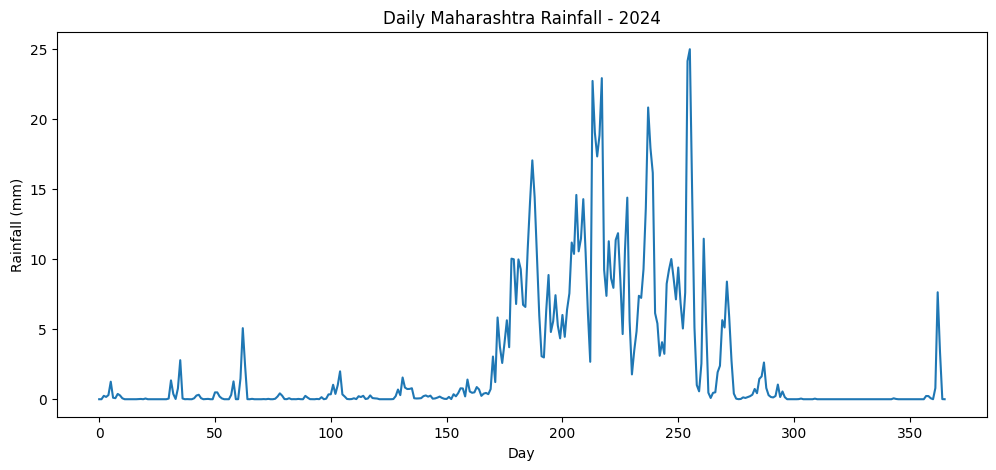

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_rain)
plt.title("Daily Maharashtra Rainfall - 2024")
plt.xlabel("Day")
plt.ylabel("Rainfall (mm)")
plt.show()

In [74]:
daily_temp = np.nanmean(
    temp,
    axis=(1,2)
)

print(daily_temp.shape)

(366,)


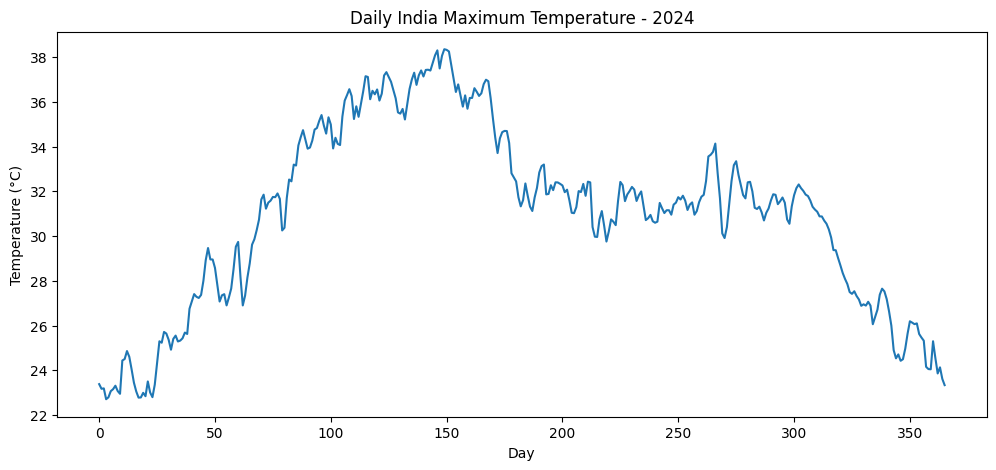

In [75]:
plt.figure(figsize=(12,5))

plt.plot(daily_temp)

plt.title("Daily India Maximum Temperature - 2024")
plt.xlabel("Day")
plt.ylabel("Temperature (°C)")

plt.show()

In [76]:
import pandas as pd

climate_df = pd.DataFrame({
    "day": np.arange(366),
    "rainfall": daily_rain,
    "temperature": daily_temp
})

climate_df.head()

,day,rainfall,temperature
0,0,0.000000,23.385981
1,1,0.000000,23.178064
2,2,0.242088,23.195887
3,3,0.163972,22.711435
4,4,0.296261,22.796724


In [77]:
print(climate_df.shape)

(366, 3)


In [78]:
climate_df.to_csv(
    "../data/processed/climate_2024.csv",
    index=False
)

In [79]:
print(
    climate_df[
        ["rainfall","temperature"]
    ].corr()
)

             rainfall  temperature
rainfall     1.000000     0.060546
temperature  0.060546     1.000000


In [2]:
import numpy as np

In [4]:
for year in range(2019, 2026):
    rain = np.fromfile(
        f"../data/raw/rainfall/Rainfall_ind{year}_rfp25.grd",
        dtype=np.float32
    )

    print(year, rain.shape)

2019 (6356475,)
2020 (6373890,)
2021 (6356475,)
2022 (6356475,)
2023 (6356475,)
2024 (6373890,)
2025 (6356475,)


In [5]:
for year in range(2019, 2026):

    rain = np.fromfile(
        f"../data/raw/rainfall/Rainfall_ind{year}_rfp25.grd",
        dtype=np.float32
    )

    days = 366 if year % 4 == 0 else 365

    print(
        year,
        rain.size,
        rain.size / (129 * 135)
    )

2019 6356475 365.0
2020 6373890 366.0
2021 6356475 365.0
2022 6356475 365.0
2023 6356475 365.0
2024 6373890 366.0
2025 6356475 365.0


In [6]:
for year in range(2019, 2026):

    rain = np.fromfile(
        f"../data/raw/rainfall/Rainfall_ind{year}_rfp25.grd",
        dtype=np.float32
    )

    days = 366 if year in [2020, 2024] else 365

    rain = rain.reshape(days,129,135)

    print(year, rain.shape)

2019 (365, 129, 135)
2020 (366, 129, 135)
2021 (365, 129, 135)
2022 (365, 129, 135)
2023 (365, 129, 135)
2024 (366, 129, 135)
2025 (365, 129, 135)


In [7]:
rain = rain.reshape(days,129,135)

print(np.min(rain))
print(np.max(rain))

-999.0
469.21014


In [8]:
import numpy as np

def load_rainfall(year):

    path = f"data/raw/rainfall/Rainfall_ind{year}_rfp25.grd"

    rain = np.fromfile(path,dtype=np.float32)

    days = 366 if year in [2020,2024] else 365

    rain = rain.reshape(days,129,135)

    rain[rain == -999] = np.nan

    return rain

In [10]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [11]:
from src.loaders import load_rainfall

In [13]:
import os

print(os.getcwd())

e:\ClimateTwinIndia\notebooks


In [14]:
import os

print(os.path.exists("data/raw/rainfall"))
print(os.path.exists("../data/raw/rainfall"))

False
True


In [18]:
import importlib
import src.loaders

importlib.reload(src.loaders)

from src.loaders import load_rainfall

In [19]:
from src.loaders import load_rainfall

rain_2024 = load_rainfall(2024)

print(rain_2024.shape)
print(np.nanmean(rain_2024))

(366, 129, 135)
3.3205583


In [20]:
all_rain = {}

for year in range(2019, 2026):
    all_rain[year] = load_rainfall(year)

    print(
        year,
        all_rain[year].shape,
        np.nanmean(all_rain[year])
    )

2019 (365, 129, 135) 3.4766786
2020 (366, 129, 135) 3.4876978
2021 (365, 129, 135) 3.356477
2022 (365, 129, 135) 3.4443238
2023 (365, 129, 135) 2.9621644
2024 (366, 129, 135) 3.3205583
2025 (365, 129, 135) 3.4739628


In [21]:
import numpy as np

vals = [3.4766786,3.4876978,3.356477,3.4443238,2.9621644,3.3205583]

print("Mean:",np.mean(vals))
print("Std:",np.std(vals))

Mean: 3.3413166499999996
Std: 0.18017488981595772


In [22]:
climatology = np.mean(vals)

print("2025 anomaly:",3.4739628-climatology)

2025 anomaly: 0.13264615000000024


In [24]:
annual_grids = []

for year in range(2019, 2025):

    annual_grid = np.nanmean(all_rain[year], axis=0)

    annual_grids.append(annual_grid)

baseline_grid = np.nanmean(
    np.stack(annual_grids),
    axis=0
)

print(baseline_grid.shape)

(129, 135)


C:\Users\Aaditya\AppData\Local\Temp\ipykernel_30688\1538901562.py:5: RuntimeWarning: Mean of empty slice
  annual_grid = np.nanmean(all_rain[year], axis=0)
C:\Users\Aaditya\AppData\Local\Temp\ipykernel_30688\1538901562.py:9: RuntimeWarning: Mean of empty slice
  baseline_grid = np.nanmean(


In [25]:
rain_2025_grid = np.nanmean(all_rain[2025], axis=0)

anomaly_grid = rain_2025_grid - baseline_grid

print(np.nanmin(anomaly_grid))
print(np.nanmax(anomaly_grid))
print(np.nanmean(anomaly_grid))

-11.494356
7.2810364
0.13265127


C:\Users\Aaditya\AppData\Local\Temp\ipykernel_30688\3162284101.py:1: RuntimeWarning: Mean of empty slice
  rain_2025_grid = np.nanmean(all_rain[2025], axis=0)


In [26]:
print(np.isnan(baseline_grid).sum())
print(baseline_grid.size)

12451
17415


In [27]:
print(
    100 * np.isnan(baseline_grid).sum() / baseline_grid.size
)

71.4958369221935


In [28]:
max_idx = np.unravel_index(
    np.nanargmax(anomaly_grid),
    anomaly_grid.shape
)

min_idx = np.unravel_index(
    np.nanargmin(anomaly_grid),
    anomaly_grid.shape
)

print("Max:", max_idx, anomaly_grid[max_idx])
print("Min:", min_idx, anomaly_grid[min_idx])

Max: (15, 42) 7.2810364
Min: (76, 97) -11.494356


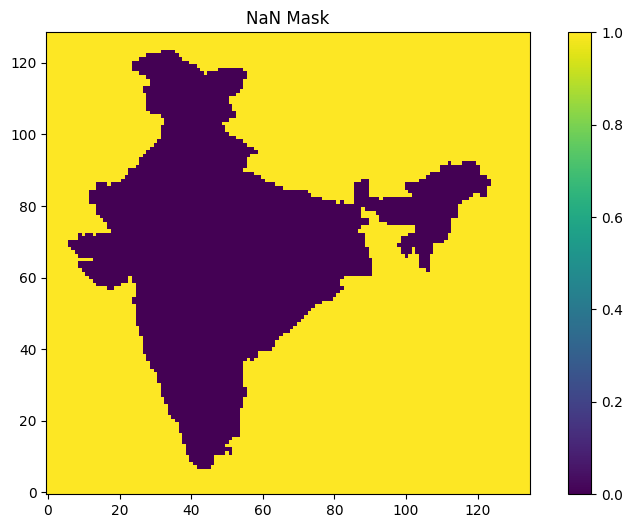

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(
    np.isnan(baseline_grid),
    origin="lower"
)

plt.colorbar()

plt.title("NaN Mask")
plt.show()

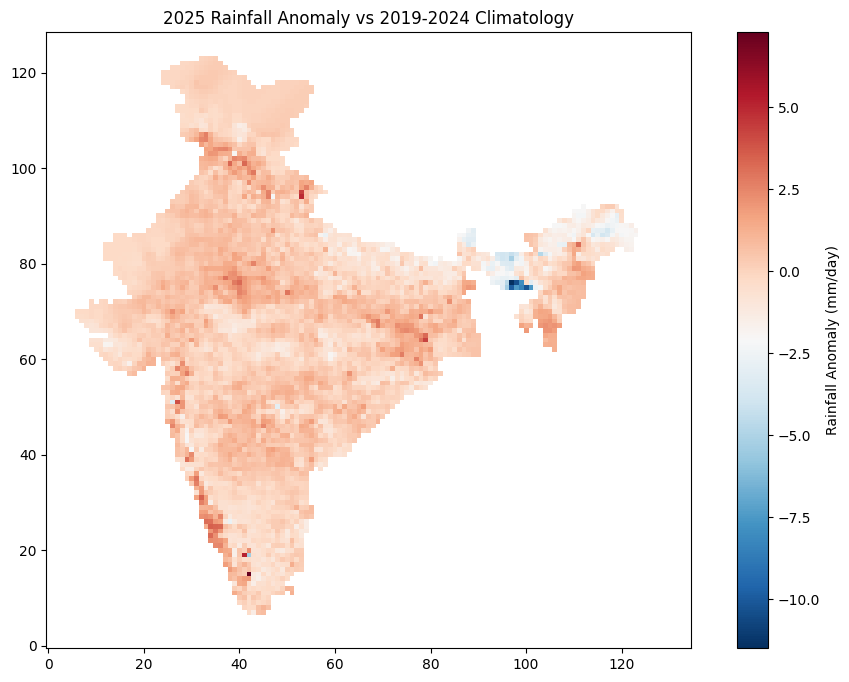

In [30]:
plt.figure(figsize=(12,8))

plt.imshow(
    anomaly_grid,
    origin="lower",
    cmap="RdBu_r"
)

plt.colorbar(
    label="Rainfall Anomaly (mm/day)"
)

plt.title(
    "2025 Rainfall Anomaly vs 2019-2024 Climatology"
)

plt.show()

In [33]:
import os

os.makedirs("docs/images", exist_ok=True)

plt.savefig(
    "docs/images/rainfall_anomaly_2025.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [12]:
from src.loaders import load_temperature

for year in range(2019, 2026):

    temp = load_temperature(year)

    print(
        year,
        temp.shape,
        np.nanmean(temp)
    )

ModuleNotFoundError: No module named 'src.loaders'

In [13]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

print(sys.path[-1])

e:\ClimateTwinIndia


In [14]:
from src.loaders import load_temperature

In [15]:
import os

print(os.getcwd())

e:\ClimateTwinIndia\notebooks


In [16]:
import os

print(os.getcwd())

print(
    os.path.exists("../src/loaders.py")
)

print(
    os.path.exists("src/loaders.py")
)

e:\ClimateTwinIndia\notebooks
True
False


In [18]:
import numpy as np


In [19]:
from src.loaders import load_temperature

for year in range(2019, 2026):

    temp = load_temperature(year)

    print(
        year,
        temp.shape,
        np.nanmean(temp)
    )

2019 (365, 31, 31) 30.6359
2020 (366, 31, 31) 30.461535
2021 (365, 31, 31) 30.712994
2022 (365, 31, 31) 30.910982
2023 (365, 31, 31) 30.869696
2024 (366, 31, 31) 30.920702
2025 (365, 31, 31) 30.604105


In [20]:
all_temp = {}

for year in range(2019, 2025):
    all_temp[year] = load_temperature(year)

annual_grids = []

for year in range(2019, 2025):

    annual_grid = np.nanmean(
        all_temp[year],
        axis=0
    )

    annual_grids.append(
        annual_grid
    )

temp_climatology = np.nanmean(
    np.stack(annual_grids),
    axis=0
)

print(temp_climatology.shape)
print(np.nanmean(temp_climatology))

(31, 31)
30.742105


C:\Users\Aaditya\AppData\Local\Temp\ipykernel_28328\2074873823.py:10: RuntimeWarning: Mean of empty slice
  annual_grid = np.nanmean(
C:\Users\Aaditya\AppData\Local\Temp\ipykernel_28328\2074873823.py:19: RuntimeWarning: Mean of empty slice
  temp_climatology = np.nanmean(


In [21]:
temp_2025 = load_temperature(2025)

temp_2025_grid = np.nanmean(
    temp_2025,
    axis=0
)

temp_anomaly = (
    temp_2025_grid
    -
    temp_climatology
)

print(
    np.nanmin(temp_anomaly),
    np.nanmax(temp_anomaly),
    np.nanmean(temp_anomaly)
)

-2.3452892 3.1097507 -0.13947092


C:\Users\Aaditya\AppData\Local\Temp\ipykernel_28328\282998520.py:3: RuntimeWarning: Mean of empty slice
  temp_2025_grid = np.nanmean(


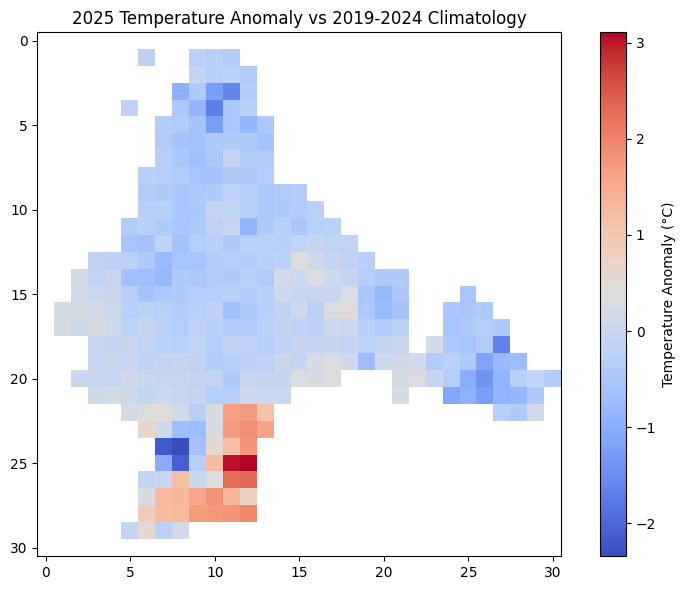

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(
    temp_anomaly,
    cmap="coolwarm"
)

plt.colorbar(
    label="Temperature Anomaly (°C)"
)

plt.title(
    "2025 Temperature Anomaly vs 2019-2024 Climatology"
)

plt.tight_layout()

plt.show()

In [23]:
print(np.nanmin(temp_anomaly))
print(np.nanmax(temp_anomaly))
print(np.nanmean(temp_anomaly))

-2.3452892
3.1097507
-0.13947092


In [26]:
from src.state_engine import create_climate_state

state = create_climate_state(
    date="2025",
    latitude=20.0,
    longitude=75.0,
    rainfall=rainfall,
    temperature=temp,
    completeness_score=1.0,
    anomaly_score=rain_anomaly
)

print(state)

NameError: name 'rainfall' is not defined

In [28]:
from src.loaders import load_rainfall, load_temperature
import numpy as np

In [29]:
all_rain = {}

for year in range(2019, 2026):
    rain = load_rainfall(year)
    all_rain[year] = rain

In [30]:
annual_grids = []

for year in range(2019, 2025):
    annual_grid = np.nanmean(all_rain[year], axis=0)
    annual_grids.append(annual_grid)

baseline_grid = np.nanmean(
    np.stack(annual_grids),
    axis=0
)

C:\Users\Aaditya\AppData\Local\Temp\ipykernel_28328\3567838942.py:4: RuntimeWarning: Mean of empty slice
  annual_grid = np.nanmean(all_rain[year], axis=0)
C:\Users\Aaditya\AppData\Local\Temp\ipykernel_28328\3567838942.py:7: RuntimeWarning: Mean of empty slice
  baseline_grid = np.nanmean(


In [31]:
rain_2025_grid = np.nanmean(
    all_rain[2025],
    axis=0
)

anomaly_grid = (
    rain_2025_grid
    -
    baseline_grid
)

C:\Users\Aaditya\AppData\Local\Temp\ipykernel_28328\2722955183.py:1: RuntimeWarning: Mean of empty slice
  rain_2025_grid = np.nanmean(


In [32]:
print(rain_2025_grid.shape)
print(anomaly_grid.shape)

(129, 135)
(129, 135)


In [33]:
temp_2025 = load_temperature(2025)

temp_2025_grid = np.nanmean(
    temp_2025,
    axis=0
)

C:\Users\Aaditya\AppData\Local\Temp\ipykernel_28328\1447540428.py:3: RuntimeWarning: Mean of empty slice
  temp_2025_grid = np.nanmean(


In [34]:
print(temp_2025_grid.shape)

(31, 31)


In [35]:
lat_idx = 50
lon_idx = 70

rainfall = rain_2025_grid[lat_idx, lon_idx]

rain_anomaly = anomaly_grid[lat_idx, lon_idx]

temp = temp_2025_grid[15, 15]

In [36]:
print(rainfall)
print(rain_anomaly)
print(temp)

4.1382456
0.20180392
31.929712


In [38]:
from src.state_engine import create_climate_state

state = create_climate_state(
    date="2025",
    latitude=20.0,
    longitude=75.0,
    rainfall=rainfall,
    temperature=temp,
    completeness_score=1.0,
    anomaly_score=rain_anomaly
)

print(state)

ClimateState(date='2025', latitude=20.0, longitude=75.0, rainfall_mm=4.1382456, max_temperature_c=31.929712, completeness_score=1.0, anomaly_score=0.20180392)


In [40]:
import os
print(os.getcwd())

e:\ClimateTwinIndia\notebooks


In [41]:
np.save(
    "../data/processed/rainfall_climatology.npy",
    baseline_grid
)

np.save(
    "../data/processed/rainfall_anomaly_2025.npy",
    anomaly_grid
)

np.save(
    "../data/processed/temp_climatology.npy",
    temp_climatology
)

np.save(
    "../data/processed/temp_anomaly_2025.npy",
    temp_anomaly
)

In [42]:
import os

print(os.listdir("../data/processed"))

['climate_2024.csv', 'rainfall_anomaly_2025.npy', 'rainfall_climatology.npy', 'temp_anomaly_2025.npy', 'temp_climatology.npy']


In [43]:
from src.climatology import *

annual_2025 = annual_mean_grid(all_rain[2025])

anomaly = compute_anomaly(
    annual_2025,
    baseline_grid
)

e:\ClimateTwinIndia\src\climatology.py:4: RuntimeWarning: Mean of empty slice
  return np.nanmean(data, axis=0)


In [44]:
annual_grid = annual_mean_grid(all_rain[2025])

print(np.isnan(annual_grid).sum())

12451


In [45]:
valid_cells = np.sum(~np.isnan(rain_2025_grid))

print(valid_cells)

4964


In [46]:
from src.state_engine import create_climate_state

states = []

for i in range(129):
    for j in range(135):

        if np.isnan(rain_2025_grid[i, j]):
            continue

        state = create_climate_state(
            date="2025",
            latitude=float(i),
            longitude=float(j),
            rainfall=float(rain_2025_grid[i, j]),
            temperature=np.nan,   # temp resolution mismatch for now
            completeness_score=1.0,
            anomaly_score=float(anomaly_grid[i, j])
        )

        states.append(state)

print(len(states))

4964


In [47]:
import pandas as pd

df = pd.DataFrame([vars(s) for s in states])

df.to_csv(
    "../data/processed/climate_states_2025.csv",
    index=False
)

print(df.head())

   date  latitude  longitude  rainfall_mm  max_temperature_c  \
0  2025       7.0       42.0     3.654722                NaN   
1  2025       7.0       43.0     2.103603                NaN   
2  2025       7.0       44.0     2.913849                NaN   
3  2025       7.0       45.0     3.199941                NaN   
4  2025       8.0       41.0     5.891756                NaN   

   completeness_score  anomaly_score  
0                 1.0      -0.414261  
1                 1.0      -1.376336  
2                 1.0       0.620547  
3                 1.0       0.815414  
4                 1.0      -0.112075  


In [48]:
lat = 6.5 + i * 0.25
lon = 66.5 + j * 0.25

In [49]:
temp_i = int(i * 31 / 129)
temp_j = int(j * 31 / 135)

temp = temp_2025_grid[temp_i, temp_j]

In [51]:
temp_i = int(i * 31 / 129)
temp_j = int(j * 31 / 135)

temp = temp_2025_grid[temp_i, temp_j]

In [52]:
temperature=float(temp)

In [53]:
df["max_temperature_c"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: max_temperature_c, dtype: float64

In [54]:

print(temp_2025_grid.shape)
print(np.nanmean(temp_2025_grid))

(31, 31)
30.602634


In [55]:
states = []

for i in range(129):
    for j in range(135):

        if np.isnan(rain_2025_grid[i, j]):
            continue

        temp_i = min(int(i * 31 / 129), 30)
        temp_j = min(int(j * 31 / 135), 30)

        temp = temp_2025_grid[temp_i, temp_j]

        state = create_climate_state(
            date="2025",
            latitude=float(i),
            longitude=float(j),
            rainfall=float(rain_2025_grid[i, j]),
            temperature=float(temp),
            completeness_score=1.0,
            anomaly_score=float(anomaly_grid[i, j])
        )

        states.append(state)

In [56]:
df = pd.DataFrame(
    [vars(s) for s in states]
)

In [57]:
df["max_temperature_c"].describe()

count    4843.000000
mean       30.807360
std         2.780137
min        21.288130
25%        30.168190
50%        31.774500
75%        32.518293
max        33.951836
Name: max_temperature_c, dtype: float64

In [58]:
print(df.shape)

print(df.isna().sum())

(4964, 7)
date                    0
latitude                0
longitude               0
rainfall_mm             0
max_temperature_c     121
completeness_score      0
anomaly_score           0
dtype: int64


In [59]:
missing = df[df["max_temperature_c"].isna()]

print(missing.head())
print(len(missing))

      date  latitude  longitude  rainfall_mm  max_temperature_c  \
24    2025      11.0       39.0     8.059662                NaN   
36    2025      12.0       39.0     8.215178                NaN   
780   2025      44.0       26.0    10.388110                NaN   
820   2025      45.0       26.0    10.844058                NaN   
1835  2025      62.0      106.0     7.066096                NaN   

      completeness_score  anomaly_score  
24                   1.0       1.380863  
36                   1.0       0.236811  
780                  1.0       0.862074  
820                  1.0       0.802259  
1835                 1.0       1.241556  
121


In [60]:
print(np.isnan(temp_2025_grid).sum())

606


In [61]:
print(temp_2025_grid.shape)

print(
    np.sum(~np.isnan(temp_2025_grid))
)

(31, 31)
355


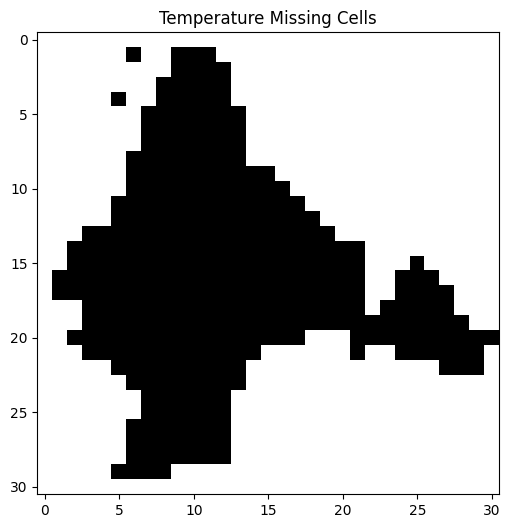

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(
    np.isnan(temp_2025_grid),
    cmap="gray"
)

plt.title(
    "Temperature Missing Cells"
)

plt.show()

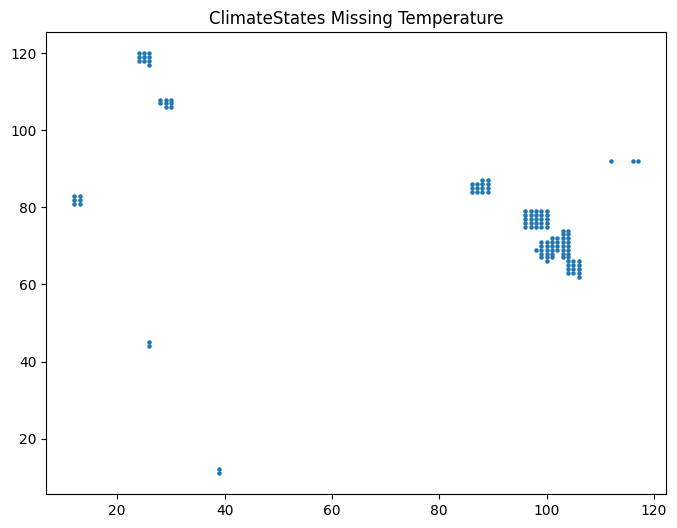

In [63]:
missing = df[df["max_temperature_c"].isna()]

plt.figure(figsize=(8,6))
plt.scatter(
    missing["longitude"],
    missing["latitude"],
    s=5
)
plt.title("ClimateStates Missing Temperature")
plt.show()

In [64]:
missing.iloc[0]

date                      2025
latitude                  11.0
longitude                 39.0
rainfall_mm           8.059662
max_temperature_c          NaN
completeness_score         1.0
anomaly_score         1.380863
Name: 24, dtype: object

In [65]:
i = 11
j = 39

temp_i = min(int(i * 31 / 129), 30)
temp_j = min(int(j * 31 / 135), 30)

print(temp_i, temp_j)

print(temp_2025_grid[temp_i, temp_j])

2 8
nan


In [66]:
temp_filled = temp_2025_grid.copy()

mean_temp = np.nanmean(temp_filled)

temp_filled[np.isnan(temp_filled)] = mean_temp

In [67]:
temp = temp_2025_grid[temp_i, temp_j]

In [68]:
df["max_temperature_c"].isna().sum()

121

In [69]:
temp_filled = temp_2025_grid.copy()

mean_temp = np.nanmean(temp_filled)

temp_filled[np.isnan(temp_filled)] = mean_temp

print(np.isnan(temp_filled).sum())

0


In [70]:
df["max_temperature_c"].isna().sum()

121

In [71]:
print(np.isnan(temp_2025_grid).sum())
print(np.isnan(temp_filled).sum())

606
0


In [72]:
print(temp_2025_grid[2,8])
print(temp_filled[2,8])

nan
30.602634


In [73]:
df["max_temperature_c"].isna().sum()

121

In [74]:
print(np.isnan(temp_filled).sum())

0


In [75]:
temp_i = 2
temp_j = 8

print(temp_2025_grid[temp_i, temp_j])
print(temp_filled[temp_i, temp_j])

nan
30.602634


In [76]:
missing = 0

for i in range(129):
    for j in range(135):

        if np.isnan(rain_2025_grid[i,j]):
            continue

        temp_i = min(int(i * 31 / 129), 30)
        temp_j = min(int(j * 31 / 135), 30)

        temp = temp_filled[temp_i, temp_j]

        if np.isnan(temp):
            missing += 1

print(missing)

0


In [77]:
states = []

for i in range(129):
    for j in range(135):

        if np.isnan(rain_2025_grid[i,j]):
            continue

        temp_i = min(int(i * 31 / 129), 30)
        temp_j = min(int(j * 31 / 135), 30)

        temp = temp_filled[temp_i, temp_j]

        state = create_climate_state(
            date="2025",
            latitude=float(i),
            longitude=float(j),
            rainfall=float(rain_2025_grid[i,j]),
            temperature=float(temp),
            completeness_score=1.0,
            anomaly_score=float(anomaly_grid[i,j])
        )

        states.append(state)

In [78]:
import pandas as pd

df = pd.DataFrame(
    [vars(s) for s in states]
)

In [79]:
print(df.shape)

print(
    df.isna().sum()
)

(4964, 7)
date                  0
latitude              0
longitude             0
rainfall_mm           0
max_temperature_c     0
completeness_score    0
anomaly_score         0
dtype: int64


In [80]:
df.to_csv(
    "../data/processed/climate_states_2025.csv",
    index=False
)

In [81]:
print(df.head())
print(df.shape)

   date  latitude  longitude  rainfall_mm  max_temperature_c  \
0  2025       7.0       42.0     3.654722          31.251387   
1  2025       7.0       43.0     2.103603          31.251387   
2  2025       7.0       44.0     2.913849          32.969940   
3  2025       7.0       45.0     3.199941          32.969940   
4  2025       8.0       41.0     5.891756          31.251387   

   completeness_score  anomaly_score  
0                 1.0      -0.414261  
1                 1.0      -1.376336  
2                 1.0       0.620547  
3                 1.0       0.815414  
4                 1.0      -0.112075  
(4964, 7)


In [82]:
# src/coordinates.py

def rainfall_idx_to_latlon(i, j):
    lat = 38.5 - (i * 0.25)
    lon = 66.5 + (j * 0.25)
    return lat, lon

In [83]:
def rainfall_idx_to_latlon(i, j):
    lat = 38.5 - (i * 0.25)
    lon = 66.5 + (j * 0.25)
    return lat, lon

print(rainfall_idx_to_latlon(7, 42))

(36.75, 77.0)


In [84]:
lat, lon = rainfall_idx_to_latlon(7, 42)

print(lat, lon)

36.75 77.0


In [86]:
lat, lon = rainfall_idx_to_latlon(i, j)

state = create_climate_state(
    date="2025",
    latitude=lat,
    longitude=lon,
    rainfall=float(rain_2025_grid[i, j]),
    temperature=float(temp),
    completeness_score=1.0,
    anomaly_score=float(anomaly_grid[i, j])
)

In [87]:
df.head()

,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score
0,2025,7.0,42.0,3.654722,31.251387,1.0,-0.414261
1,2025,7.0,43.0,2.103603,31.251387,1.0,-1.376336
2,2025,7.0,44.0,2.913849,32.969940,1.0,0.620547
3,2025,7.0,45.0,3.199941,32.969940,1.0,0.815414
4,2025,8.0,41.0,5.891756,31.251387,1.0,-0.112075


In [88]:
states = []

In [89]:
lat, lon = rainfall_idx_to_latlon(i, j)

state = create_climate_state(
    date="2025",
    latitude=lat,
    longitude=lon,
    rainfall=float(rain_2025_grid[i, j]),
    temperature=float(temp),
    completeness_score=1.0,
    anomaly_score=float(anomaly_grid[i, j])
)

In [90]:
states.append(state)

In [91]:
import pandas as pd

df = pd.DataFrame(
    [vars(s) for s in states]
)

In [92]:
print(df.head())

   date  latitude  longitude  rainfall_mm  max_temperature_c  \
0  2025       6.5      100.0          NaN          21.812681   

   completeness_score  anomaly_score  
0                 1.0            NaN  


In [93]:
print(rainfall_idx_to_latlon(7,42))

(36.75, 77.0)


In [94]:
print(len(states))

1


In [95]:
states[0]

ClimateState(date='2025', latitude=6.5, longitude=100.0, rainfall_mm=nan, max_temperature_c=21.812681198120117, completeness_score=1.0, anomaly_score=nan)

In [96]:
print(len(states))

1


In [97]:
states = []

for i in range(129):
    for j in range(135):

        if np.isnan(rain_2025_grid[i, j]):
            continue

        temp_i = min(int(i * 31 / 129), 30)
        temp_j = min(int(j * 31 / 135), 30)

        temp = temp_filled[temp_i, temp_j]

        lat, lon = rainfall_idx_to_latlon(i, j)

        state = create_climate_state(
            date="2025",
            latitude=lat,
            longitude=lon,
            rainfall=float(rain_2025_grid[i, j]),
            temperature=float(temp),
            completeness_score=1.0,
            anomaly_score=float(anomaly_grid[i, j])
        )

        states.append(state)

In [98]:
print(len(states))

4964


In [99]:
df = pd.DataFrame([vars(s) for s in states])

print(df.head())

   date  latitude  longitude  rainfall_mm  max_temperature_c  \
0  2025     36.75      77.00     3.654722          31.251387   
1  2025     36.75      77.25     2.103603          31.251387   
2  2025     36.75      77.50     2.913849          32.969940   
3  2025     36.75      77.75     3.199941          32.969940   
4  2025     36.50      76.75     5.891756          31.251387   

   completeness_score  anomaly_score  
0                 1.0      -0.414261  
1                 1.0      -1.376336  
2                 1.0       0.620547  
3                 1.0       0.815414  
4                 1.0      -0.112075  


In [100]:
print(df.shape)

(4964, 7)


In [101]:
df.to_csv(
    "../data/processed/climate_states_2025.csv",
    index=False
)

In [102]:
from src.climate_database import save_climate_database

In [103]:
df = pd.DataFrame(
    [vars(s) for s in states]
)

df.to_csv(
    "../data/processed/climate_states_2025.csv",
    index=False
)

In [104]:
df = save_climate_database(
    states,
    "../data/processed/climate_states_2025.csv"
)

In [105]:
from src.climate_database import save_climate_database

df = save_climate_database(
    states,
    "../data/processed/climate_states_2025.csv"
)

print(df.shape)

(4964, 7)


In [106]:
from src.database_builder import build_climate_states

states_2024 = build_climate_states(
    2024,
    baseline_grid
)

len(states_2024)

e:\ClimateTwinIndia\src\database_builder.py:16: RuntimeWarning: Mean of empty slice
  rain_grid = np.nanmean(
e:\ClimateTwinIndia\src\database_builder.py:21: RuntimeWarning: Mean of empty slice
  temp_grid = np.nanmean(


4964

In [107]:
from src.climate_database import save_climate_database

df_2024 = save_climate_database(
    states_2024,
    "../data/processed/climate_states_2024.csv"
)

df_2024.shape

(4964, 7)

In [108]:
for year in range(2019, 2026):

    states = build_climate_states(
        year,
        baseline_grid
    )

    save_climate_database(
        states,
        f"../data/processed/climate_states_{year}.csv"
    )

    print(year, "done")

2019 done
2020 done
2021 done
2022 done
2023 done
2024 done
2025 done


In [109]:
def annual_temperature_trend(df):

    return (
        df.groupby("year")
        ["max_temperature_c"]
        .mean()
        .reset_index()
    )

In [110]:
def annual_rainfall_trend(df):

    return (
        df.groupby("year")
        ["rainfall_mm"]
        .mean()
        .reset_index()
    )

In [113]:
import os

print(os.getcwd())

e:\ClimateTwinIndia\notebooks


In [114]:
import os

print(os.listdir())

['01_imd_exploration.ipynb', 'docs']


In [115]:
from importlib import reload
import src.climate_analysis

reload(src.climate_analysis)

from src.climate_analysis import load_all_years

In [116]:
df = load_all_years()

print(df.shape)

(34748, 8)


In [117]:
import os

print(
    os.listdir("../data/processed")
)

['climate_2024.csv', 'climate_states_2019.csv', 'climate_states_2020.csv', 'climate_states_2021.csv', 'climate_states_2022.csv', 'climate_states_2023.csv', 'climate_states_2024.csv', 'climate_states_2025.csv', 'rainfall_anomaly_2025.npy', 'rainfall_climatology.npy', 'temp_anomaly_2025.npy', 'temp_climatology.npy']


In [118]:
from importlib import reload
import src.climate_analysis

reload(src.climate_analysis)

from src.climate_analysis import load_all_years

df = load_all_years()

print(df.shape)
df.head()

(34748, 8)


,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score,year
0,2019,36.75,77.00,3.331672,31.718817,1.0,-0.737311,2019
1,2019,36.75,77.25,3.166381,31.718817,1.0,-0.313557,2019
2,2019,36.75,77.50,2.666646,33.467411,1.0,0.373344,2019
3,2019,36.75,77.75,2.790045,33.467411,1.0,0.405518,2019
4,2019,36.50,76.75,5.099447,31.718817,1.0,-0.904384,2019


In [120]:
from importlib import reload

import src.climate_analysis

reload(src.climate_analysis)

<module 'src.climate_analysis' from 'e:\\ClimateTwinIndia\\src\\climate_analysis.py'>

In [121]:
from src.climate_analysis import annual_temperature_trend

annual_temperature_trend(df)

,year,max_temperature_c
0,2019,30.865413
1,2020,30.680312
2,2021,30.912408
3,2022,31.171071
4,2023,31.062242
5,2024,31.150929
6,2025,30.802370


In [127]:
from importlib import reload
import src.climate_analysis

reload(src.climate_analysis)

<module 'src.climate_analysis' from 'e:\\ClimateTwinIndia\\src\\climate_analysis.py'>

In [128]:
from src.climate_analysis import annual_rainfall_trend

annual_rainfall_trend(df)

,year,rainfall_mm
0,2019,3.476680
1,2020,3.487696
2,2021,3.356478
3,2022,3.444323
4,2023,2.962140
5,2024,3.320558
6,2025,3.473964


In [129]:
from src.climate_analysis import top_anomaly_locations

top_anomaly_locations(df)

,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score,year
17944,2022,19.50,90.75,33.883526,30.907879,1.0,12.850145,2022
7926,2020,19.75,91.75,26.880648,28.419184,1.0,11.287101,2020
17945,2022,19.50,91.00,32.405315,30.907879,1.0,10.867144,2022
17850,2022,19.75,90.75,34.589737,30.907879,1.0,10.406290,2022
7925,2020,19.75,91.50,35.456295,30.445829,1.0,8.625317,2020
8017,2020,19.50,91.00,29.232061,30.445829,1.0,7.693890,2020
8016,2020,19.50,90.75,28.647547,30.445829,1.0,7.614166,2020
29861,2025,34.75,77.00,18.437214,28.818054,1.0,7.281036,2025
7924,2020,19.75,91.25,37.188488,30.445829,1.0,6.890797,2020
7922,2020,19.75,90.75,30.898413,30.445829,1.0,6.714966,2020


In [132]:
hottest_locations(df)

NameError: name 'hottest_locations' is not defined

<Axes: xlabel='year'>

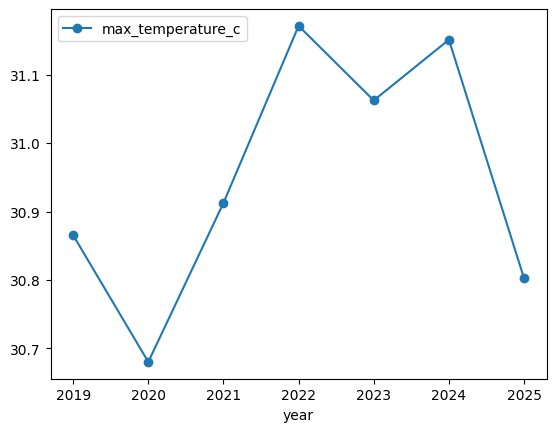

In [131]:
temp_trend = annual_temperature_trend(df)

temp_trend.plot(
    x="year",
    y="max_temperature_c",
    marker="o"
)

In [133]:
from importlib import reload
import src.climate_analysis

reload(src.climate_analysis)

<module 'src.climate_analysis' from 'e:\\ClimateTwinIndia\\src\\climate_analysis.py'>

In [134]:
from src.climate_analysis import hottest_locations

hottest_locations(df)

,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score,year
508,2019,29.75,78.75,1.817249,35.065605,1.0,-0.374361,2019
562,2019,29.25,79.00,2.202332,35.065605,1.0,-0.309922,2019
481,2019,30.00,78.50,2.298876,35.065605,1.0,-0.331189,2019
509,2019,29.75,79.00,2.131820,35.065605,1.0,-0.186491,2019
507,2019,29.75,78.50,2.943659,35.065605,1.0,0.170552,2019
535,2019,29.50,79.00,1.937107,35.065605,1.0,-0.210980,2019
534,2019,29.50,78.75,1.743821,35.065605,1.0,-0.332676,2019
533,2019,29.50,78.50,2.188120,35.065605,1.0,-0.182204,2019
536,2019,29.50,79.25,1.775938,35.065605,1.0,-0.266629,2019
511,2019,29.75,79.50,2.176887,35.065605,1.0,-0.688672,2019


In [135]:
from src.climate_analysis import top_anomaly_locations

top_anomaly_locations(df)

,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score,year
17944,2022,19.50,90.75,33.883526,30.907879,1.0,12.850145,2022
7926,2020,19.75,91.75,26.880648,28.419184,1.0,11.287101,2020
17945,2022,19.50,91.00,32.405315,30.907879,1.0,10.867144,2022
17850,2022,19.75,90.75,34.589737,30.907879,1.0,10.406290,2022
7925,2020,19.75,91.50,35.456295,30.445829,1.0,8.625317,2020
8017,2020,19.50,91.00,29.232061,30.445829,1.0,7.693890,2020
8016,2020,19.50,90.75,28.647547,30.445829,1.0,7.614166,2020
29861,2025,34.75,77.00,18.437214,28.818054,1.0,7.281036,2025
7924,2020,19.75,91.25,37.188488,30.445829,1.0,6.890797,2020
7922,2020,19.75,90.75,30.898413,30.445829,1.0,6.714966,2020


<Axes: title={'center': 'Average Rainfall (2019-2025)'}, xlabel='year'>

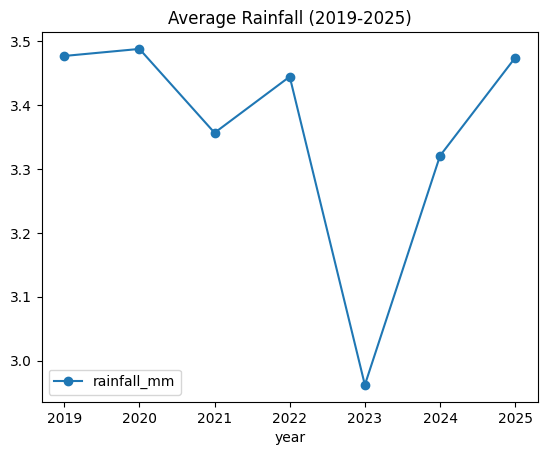

In [136]:
rain_trend = annual_rainfall_trend(df)

rain_trend.plot(
    x="year",
    y="rainfall_mm",
    marker="o",
    title="Average Rainfall (2019-2025)"
)

In [144]:
from importlib import reload
import src.climate_analysis

reload(src.climate_analysis)

<module 'src.climate_analysis' from 'e:\\ClimateTwinIndia\\src\\climate_analysis.py'>

In [145]:
from importlib import reload
import src.climate_analysis

reload(src.climate_analysis)

<module 'src.climate_analysis' from 'e:\\ClimateTwinIndia\\src\\climate_analysis.py'>

In [146]:
from src.climate_analysis import climate_summary

climate_summary(df)

{'avg_temp': 30.949249355842674,
 'avg_rain': 3.3602626979580683,
 'max_temp': 35.06560516357422,
 'max_rain': 37.1884880065918,
 'records': 34748}

In [147]:
print(climate_summary(df))
print()
print(hottest_locations(df, 10))
print()
print(wettest_locations(df, 10))

{'avg_temp': 30.949249355842674, 'avg_rain': 3.3602626979580683, 'max_temp': 35.06560516357422, 'max_rain': 37.1884880065918, 'records': 34748}

     date  latitude  longitude  rainfall_mm  max_temperature_c  \
508  2019     29.75      78.75     1.817249          35.065605   
562  2019     29.25      79.00     2.202332          35.065605   
481  2019     30.00      78.50     2.298876          35.065605   
509  2019     29.75      79.00     2.131820          35.065605   
507  2019     29.75      78.50     2.943659          35.065605   
535  2019     29.50      79.00     1.937107          35.065605   
534  2019     29.50      78.75     1.743821          35.065605   
533  2019     29.50      78.50     2.188120          35.065605   
536  2019     29.50      79.25     1.775938          35.065605   
511  2019     29.75      79.50     2.176887          35.065605   

     completeness_score  anomaly_score  year  
508                 1.0      -0.374361  2019  
562                 1.0      -0.30

NameError: name 'wettest_locations' is not defined

In [152]:
from importlib import reload
import src.climate_analysis

reload(src.climate_analysis)

<module 'src.climate_analysis' from 'e:\\ClimateTwinIndia\\src\\climate_analysis.py'>

In [149]:
from src.climate_analysis import wettest_locations

wettest_locations(df, 10)

,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score,year
7924,2020,19.75,91.25,37.188488,30.445829,1.0,6.890797,2020
17852,2022,19.75,91.25,36.366596,30.907879,1.0,6.068905,2022
7925,2020,19.75,91.50,35.456295,30.445829,1.0,8.625317,2020
17850,2022,19.75,90.75,34.589737,30.907879,1.0,10.406290,2022
17851,2022,19.75,91.00,34.349709,30.907879,1.0,6.502230,2022
17944,2022,19.50,90.75,33.883526,30.907879,1.0,12.850145,2022
17853,2022,19.75,91.50,33.398811,30.907879,1.0,6.567833,2022
7923,2020,19.75,91.00,32.948212,30.445829,1.0,5.100733,2020
17945,2022,19.50,91.00,32.405315,30.907879,1.0,10.867144,2022
27780,2024,19.75,91.25,31.168758,30.911053,1.0,0.871067,2024


In [155]:
from importlib import reload
import src.climate_analysis

reload(src.climate_analysis)

<module 'src.climate_analysis' from 'e:\\ClimateTwinIndia\\src\\climate_analysis.py'>

In [156]:
from src.climate_analysis import annual_climate_summary

summary = annual_climate_summary(df)

print(summary)

   year  max_temperature_c  rainfall_mm  anomaly_score
0  2019          30.865413     3.476680       0.135367
1  2020          30.680312     3.487696       0.146384
2  2021          30.912408     3.356478       0.015166
3  2022          31.171071     3.444323       0.103010
4  2023          31.062242     2.962140      -0.379173
5  2024          31.150929     3.320558      -0.020754
6  2025          30.802370     3.473964       0.132651


In [157]:
print(df.shape)

print(df["year"].value_counts())

print(df.describe())

(34748, 8)
year
2019    4964
2020    4964
2021    4964
2022    4964
2023    4964
2024    4964
2025    4964
Name: count, dtype: int64
               date      latitude     longitude   rainfall_mm  \
count  34748.000000  34748.000000  34748.000000  34748.000000   
mean    2022.000000     21.387540     79.459962      3.360263   
std        2.000029      6.038692      6.032767      2.365407   
min     2019.000000      7.750000     68.000000      0.000000   
25%     2020.000000     17.750000     75.250000      1.984663   
50%     2022.000000     21.000000     78.250000      2.923370   
75%     2024.000000     25.250000     82.250000      4.022578   
max     2025.000000     36.750000     97.250000     37.188488   

       max_temperature_c  completeness_score  anomaly_score          year  
count       34748.000000             34748.0   34748.000000  34748.000000  
mean           30.949249                 1.0       0.018950   2022.000000  
std             2.992809                 0.0       0.

In [159]:
from importlib import reload
import src.climate_analysis

reload(src.climate_analysis)

<module 'src.climate_analysis' from 'e:\\ClimateTwinIndia\\src\\climate_analysis.py'>

In [161]:
from importlib import reload
import src.climate_analysis

reload(src.climate_analysis)

<module 'src.climate_analysis' from 'e:\\ClimateTwinIndia\\src\\climate_analysis.py'>

In [162]:
from src.climate_analysis import (
    strongest_positive_anomalies,
    strongest_negative_anomalies
)

In [163]:
strongest_positive_anomalies(df, 10)

,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score,year
17944,2022,19.50,90.75,33.883526,30.907879,1.0,12.850145,2022
7926,2020,19.75,91.75,26.880648,28.419184,1.0,11.287101,2020
17945,2022,19.50,91.00,32.405315,30.907879,1.0,10.867144,2022
17850,2022,19.75,90.75,34.589737,30.907879,1.0,10.406290,2022
7925,2020,19.75,91.50,35.456295,30.445829,1.0,8.625317,2020
8017,2020,19.50,91.00,29.232061,30.445829,1.0,7.693890,2020
8016,2020,19.50,90.75,28.647547,30.445829,1.0,7.614166,2020
29861,2025,34.75,77.00,18.437214,28.818054,1.0,7.281036,2025
7924,2020,19.75,91.25,37.188488,30.445829,1.0,6.890797,2020
7922,2020,19.75,90.75,30.898413,30.445829,1.0,6.714966,2020


In [164]:
strongest_negative_anomalies(df, 10)

,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score,year
32836,2025,19.50,90.75,9.539024,30.602634,1.0,-11.494356,2025
22908,2023,19.50,90.75,9.721291,30.866726,1.0,-11.312090,2023
32837,2025,19.50,91.00,11.172183,30.602634,1.0,-10.365989,2025
32745,2025,19.75,91.50,16.589584,30.602634,1.0,-10.241394,2025
27872,2024,19.50,90.75,10.939829,30.911053,1.0,-10.093552,2024
32742,2025,19.75,90.75,14.239305,30.602634,1.0,-9.944141,2025
22909,2023,19.50,91.00,11.951097,30.866726,1.0,-9.587075,2023
32744,2025,19.75,91.25,21.906561,30.602634,1.0,-8.391130,2025
22814,2023,19.75,90.75,16.022551,30.866726,1.0,-8.160896,2023
32838,2025,19.50,91.25,14.329947,30.602634,1.0,-7.962077,2025


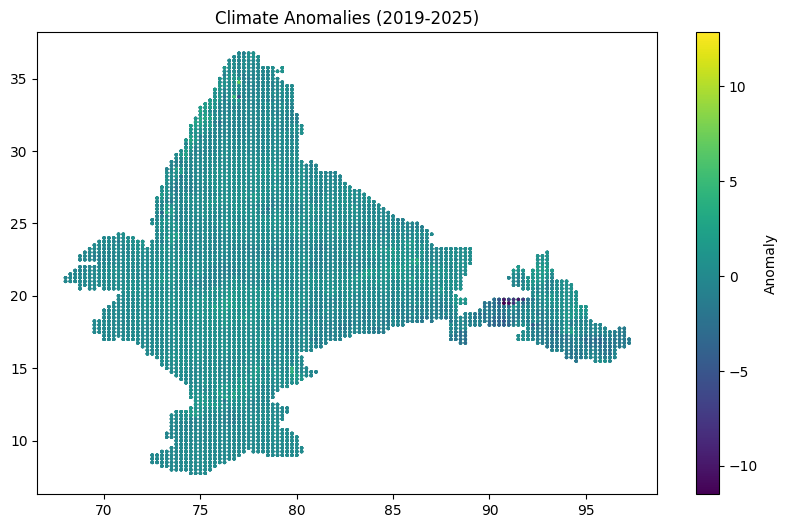

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["anomaly_score"],
    s=2
)

plt.colorbar(label="Anomaly")

plt.title(
    "Climate Anomalies (2019-2025)"
)

plt.show()

In [166]:
strongest_negative_anomalies(df, 20)

,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score,year
32836,2025,19.50,90.75,9.539024,30.602634,1.0,-11.494356,2025
22908,2023,19.50,90.75,9.721291,30.866726,1.0,-11.312090,2023
32837,2025,19.50,91.00,11.172183,30.602634,1.0,-10.365989,2025
32745,2025,19.75,91.50,16.589584,30.602634,1.0,-10.241394,2025
27872,2024,19.50,90.75,10.939829,30.911053,1.0,-10.093552,2024
32742,2025,19.75,90.75,14.239305,30.602634,1.0,-9.944141,2025
22909,2023,19.50,91.00,11.951097,30.866726,1.0,-9.587075,2023
32744,2025,19.75,91.25,21.906561,30.602634,1.0,-8.391130,2025
22814,2023,19.75,90.75,16.022551,30.866726,1.0,-8.160896,2023
32838,2025,19.50,91.25,14.329947,30.602634,1.0,-7.962077,2025


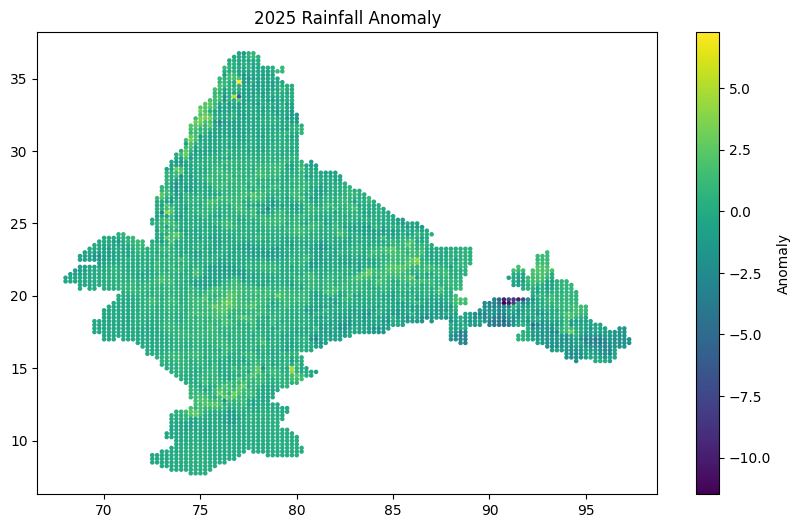

In [167]:
df_2025 = df[df["year"] == 2025]

plt.figure(figsize=(10,6))

plt.scatter(
    df_2025["longitude"],
    df_2025["latitude"],
    c=df_2025["anomaly_score"],
    s=5
)

plt.colorbar(label="Anomaly")

plt.title("2025 Rainfall Anomaly")
plt.show()

In [169]:
from importlib import reload
import src.climate_analysis

reload(src.climate_analysis)

<module 'src.climate_analysis' from 'e:\\ClimateTwinIndia\\src\\climate_analysis.py'>

In [170]:
from src.climate_analysis import (
    strongest_positive_anomalies,
    strongest_negative_anomalies
)

In [171]:
yearly_anomaly_map(df, 2019)
yearly_anomaly_map(df, 2020)
yearly_anomaly_map(df, 2021)
yearly_anomaly_map(df, 2022)
yearly_anomaly_map(df, 2023)
yearly_anomaly_map(df, 2024)
yearly_anomaly_map(df, 2025)

NameError: name 'yearly_anomaly_map' is not defined

In [172]:
strongest_positive_anomalies(df, 20)

,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score,year
17944,2022,19.50,90.75,33.883526,30.907879,1.0,12.850145,2022
7926,2020,19.75,91.75,26.880648,28.419184,1.0,11.287101,2020
17945,2022,19.50,91.00,32.405315,30.907879,1.0,10.867144,2022
17850,2022,19.75,90.75,34.589737,30.907879,1.0,10.406290,2022
7925,2020,19.75,91.50,35.456295,30.445829,1.0,8.625317,2020
8017,2020,19.50,91.00,29.232061,30.445829,1.0,7.693890,2020
8016,2020,19.50,90.75,28.647547,30.445829,1.0,7.614166,2020
29861,2025,34.75,77.00,18.437214,28.818054,1.0,7.281036,2025
7924,2020,19.75,91.25,37.188488,30.445829,1.0,6.890797,2020
7922,2020,19.75,90.75,30.898413,30.445829,1.0,6.714966,2020


In [173]:
strongest_negative_anomalies(df, 20)

,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score,year
32836,2025,19.50,90.75,9.539024,30.602634,1.0,-11.494356,2025
22908,2023,19.50,90.75,9.721291,30.866726,1.0,-11.312090,2023
32837,2025,19.50,91.00,11.172183,30.602634,1.0,-10.365989,2025
32745,2025,19.75,91.50,16.589584,30.602634,1.0,-10.241394,2025
27872,2024,19.50,90.75,10.939829,30.911053,1.0,-10.093552,2024
32742,2025,19.75,90.75,14.239305,30.602634,1.0,-9.944141,2025
22909,2023,19.50,91.00,11.951097,30.866726,1.0,-9.587075,2023
32744,2025,19.75,91.25,21.906561,30.602634,1.0,-8.391130,2025
22814,2023,19.75,90.75,16.022551,30.866726,1.0,-8.160896,2023
32838,2025,19.50,91.25,14.329947,30.602634,1.0,-7.962077,2025


In [174]:
df_2025 = df[df["year"] == 2025]

print(
    strongest_positive_anomalies(
        df_2025,
        20
    )
)

print()

print(
    strongest_negative_anomalies(
        df_2025,
        20
    )
)

       date  latitude  longitude  rainfall_mm  max_temperature_c  \
29861  2025     34.75      77.00    18.437214          28.818054   
29925  2025     33.75      76.75     8.909527          28.555273   
34111  2025     15.00      79.75    12.493217          28.483498   
34140  2025     14.75      79.75    11.294106          28.483498   
31775  2025     22.50      86.25     8.397790          31.855562   
30877  2025     25.75      73.25    11.603266          31.562960   
30037  2025     32.25      75.00    14.027701          29.825104   
30176  2025     30.75      74.50    17.510042          30.910702   
30038  2025     32.25      75.25    13.741089          29.515432   
34274  2025     13.25      76.75     7.324774          26.192236   
34271  2025     13.25      76.00     4.945719          26.571220   
30039  2025     32.25      75.50    11.674871          29.515432   
31856  2025     22.25      86.25     7.050773          31.855562   
29995  2025     32.75      75.00    12.877689   

In [175]:
def anomaly_hotspots(df, threshold=5):

    return df[
        abs(df["anomaly_score"]) >= threshold
    ]

In [176]:
hotspots = anomaly_hotspots(
    df[df["year"] == 2025],
    threshold=5
)

print(hotspots.shape)

(13, 8)


In [177]:
hotspots

,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score,year
29861,2025,34.75,77.00,18.437214,28.818054,1.0,7.281036,2025
29925,2025,33.75,76.75,8.909527,28.555273,1.0,5.149227,2025
29926,2025,33.75,77.00,2.678496,28.555273,1.0,-5.392466,2025
32741,2025,19.75,90.50,10.680436,30.602634,1.0,-5.288937,2025
32742,2025,19.75,90.75,14.239305,30.602634,1.0,-9.944141,2025
32743,2025,19.75,91.00,20.446770,30.602634,1.0,-7.400709,2025
32744,2025,19.75,91.25,21.906561,30.602634,1.0,-8.391130,2025
32745,2025,19.75,91.50,16.589584,30.602634,1.0,-10.241394,2025
32746,2025,19.75,91.75,8.071321,29.198946,1.0,-7.522225,2025
32836,2025,19.50,90.75,9.539024,30.602634,1.0,-11.494356,2025


In [178]:
hotspots.sort_values(
    "anomaly_score"
)

,date,latitude,longitude,rainfall_mm,max_temperature_c,completeness_score,anomaly_score,year
32836,2025,19.50,90.75,9.539024,30.602634,1.0,-11.494356,2025
32837,2025,19.50,91.00,11.172183,30.602634,1.0,-10.365989,2025
32745,2025,19.75,91.50,16.589584,30.602634,1.0,-10.241394,2025
32742,2025,19.75,90.75,14.239305,30.602634,1.0,-9.944141,2025
32744,2025,19.75,91.25,21.906561,30.602634,1.0,-8.391130,2025
32838,2025,19.50,91.25,14.329947,30.602634,1.0,-7.962077,2025
32746,2025,19.75,91.75,8.071321,29.198946,1.0,-7.522225,2025
32743,2025,19.75,91.00,20.446770,30.602634,1.0,-7.400709,2025
29926,2025,33.75,77.00,2.678496,28.555273,1.0,-5.392466,2025
32741,2025,19.75,90.50,10.680436,30.602634,1.0,-5.288937,2025


In [179]:
hotspots["risk"] = hotspots[
    "anomaly_score"
].apply(classify_risk)

hotspots[
    [
        "latitude",
        "longitude",
        "anomaly_score",
        "risk"
    ]
]

NameError: name 'classify_risk' is not defined